About Dataset
Credit Card Fraud: Analysis and Prevention Overview Credit card fraud represents a significant threat to the integrity of financial transactions and consumer trust in digital commerce. As the reliance on credit cards for everyday purchases continues to grow, so does the sophistication of fraudsters exploiting vulnerabilities in the system. This project aims to analyze patterns of credit card fraud, understand the factors contributing to fraudulent activities, and explore effective methods for detection and prevention.

Dataset Description The dataset comprises 100,000 transactions generated to simulate real-world credit card activity. Each entry includes the following features:

TransactionID: A unique identifier for each transaction, ensuring traceability. TransactionDate: The date and time when the transaction occurred, allowing for temporal analysis. Amount: The monetary value of the transaction, which can help identify unusually large transactions that may indicate fraud. MerchantID: An identifier for the merchant involved in the transaction, useful for assessing merchant-related fraud patterns. TransactionType: Indicates whether the transaction was a purchase or a refund, providing context for the activity. Location: The geographic location of the transaction, facilitating analysis of fraud trends by region. IsFraud: A binary target variable indicating whether the transaction is fraudulent (1) or legitimate (0), essential for supervised learning models.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('credit_card_fraud_dataset.csv')
df

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [3]:
df.head()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [4]:
df.tail()

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0
99999,100000,2024-03-05 19:41:36.027606,1596.79,675,refund,Houston,0


In [5]:
## Summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   TransactionID    100000 non-null  int64  
 1   TransactionDate  100000 non-null  object 
 2   Amount           100000 non-null  float64
 3   MerchantID       100000 non-null  int64  
 4   TransactionType  100000 non-null  object 
 5   Location         100000 non-null  object 
 6   IsFraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


In [6]:
## descriptive summary of the dataset
df.describe()

,TransactionID,Amount,MerchantID,IsFraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


In [7]:
df.shape

(100000, 7)

In [8]:
## List down all the columns names
df.columns

Index(['TransactionID', 'TransactionDate', 'Amount', 'MerchantID',
       'TransactionType', 'Location', 'IsFraud'],
      dtype='object')

In [9]:
## Missing values in the dataset

df.isnull().sum()

TransactionID      0
TransactionDate    0
Amount             0
MerchantID         0
TransactionType    0
Location           0
IsFraud            0
dtype: int64

In [10]:
df["Amount"] = df["Amount"].fillna(df["Amount"].mean())

In [11]:
df["MerchantID"] = df["MerchantID"].fillna(df["MerchantID"].mean())

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df

,TransactionID,TransactionDate,Amount,MerchantID,TransactionType,Location,IsFraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0
...,...,...,...,...,...,...,...
99995,99996,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,0
99996,99997,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,0
99997,99998,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,0
99998,99999,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,0


In [15]:
def find_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]

In [16]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    print(col, find_outliers(df, col).shape)

TransactionID (0, 7)
Amount (0, 7)
MerchantID (0, 7)
IsFraud (1000, 7)


In [17]:
import numpy as np

def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_range = Q1 - 1.5 * IQR
    upper_range = Q3 + 1.5 * IQR

    # Define outliers
    outliers = df[(df[col] > upper_range) | (df[col] < lower_range)]

    print(f"{col} - Number of outliers:", outliers.shape[0])

    # Cap values
    df[col] = np.where(df[col] > upper_range, upper_range, df[col])
    df[col] = np.where(df[col] < lower_range, lower_range, df[col])

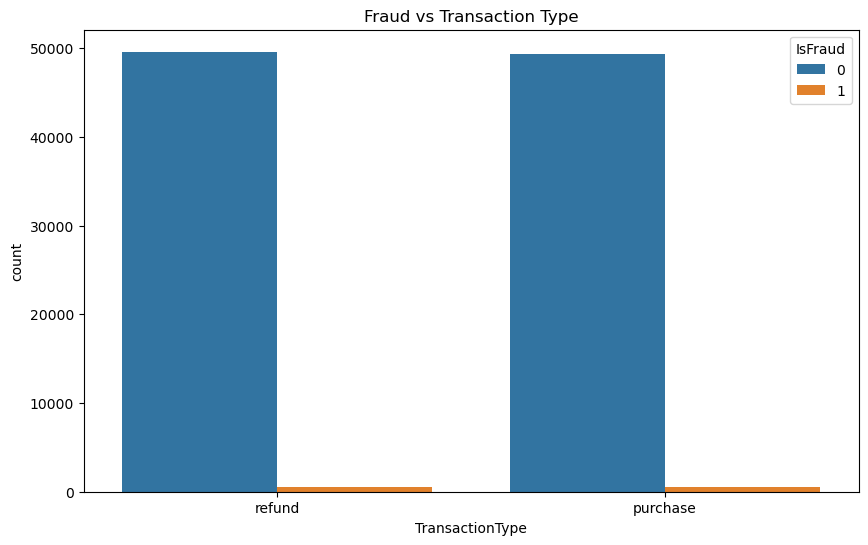

In [18]:
plt.figure(figsize=(10,6))
sns.countplot(x="TransactionType", hue="IsFraud", data=df)
plt.title("Fraud vs Transaction Type")
plt.show()

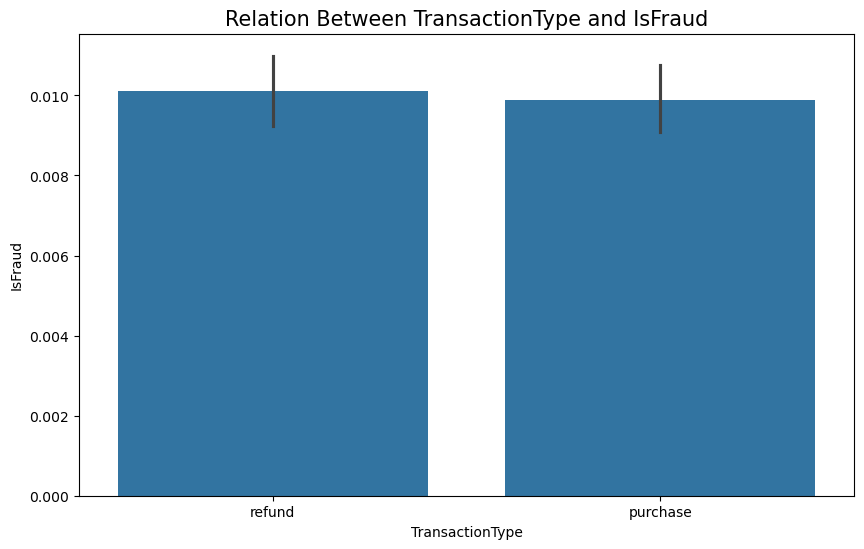

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(x=df["TransactionType"], y=df["IsFraud"])
plt.title("Relation Between TransactionType and IsFraud", size=15)
plt.show()

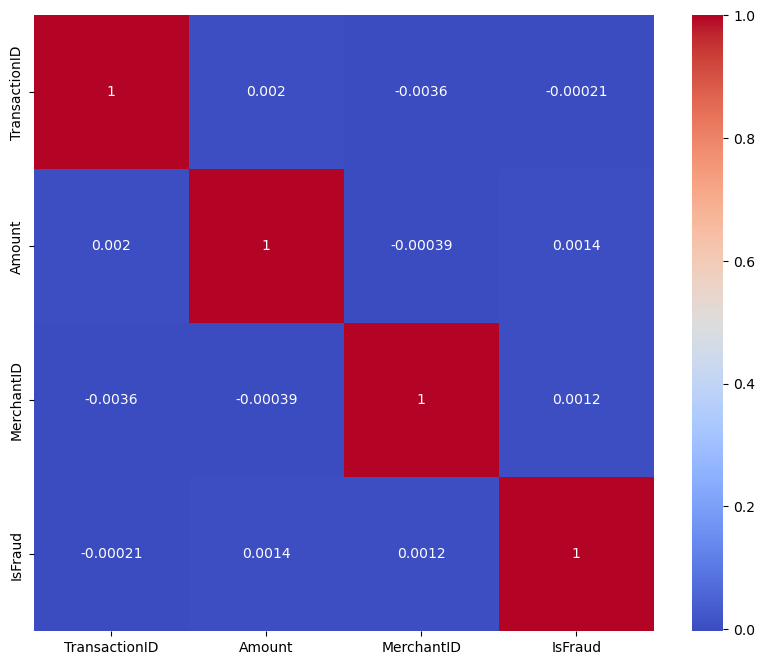

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [21]:
num_cols = df.select_dtypes(include='number').columns

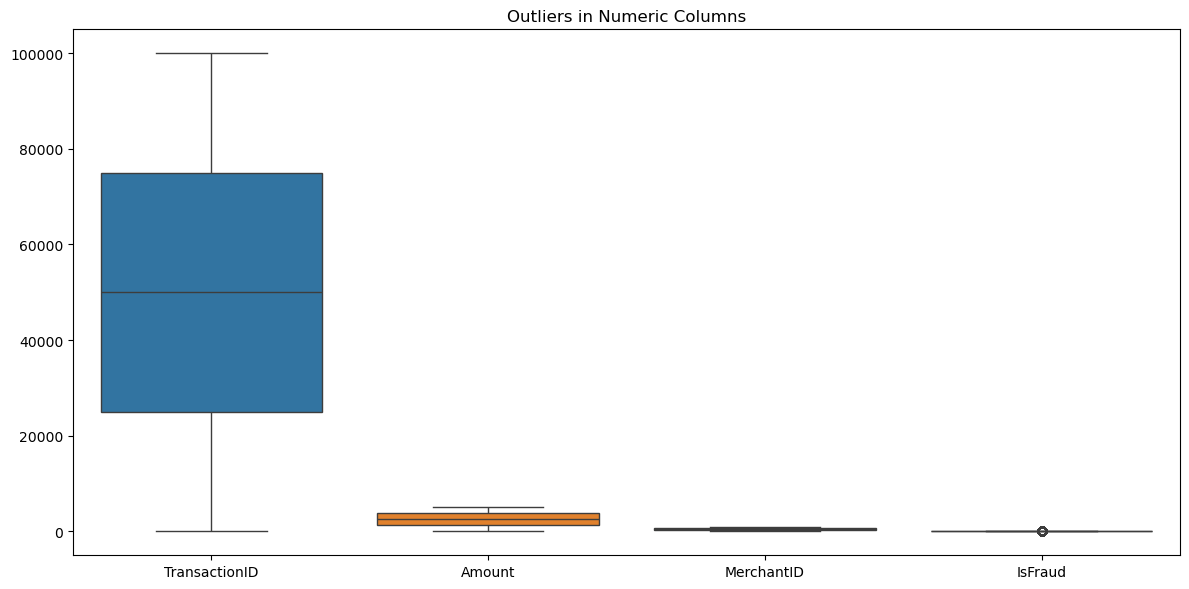

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols])
plt.title('Outliers in Numeric Columns')
plt.tight_layout()
plt.show()

# One-Hot Encoding (already in dataset — kept for reference)

In [23]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [24]:
## Create a simple dataframe 
df_color = pd.DataFrame({
    'color': ['red', 'blue', 'green', 'green', 'red', 'blue']
})

In [25]:
encoder=OneHotEncoder()
encoded=encoder.fit_transform(df_color[['color']]).toarray()
encoder_df=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())
encoder_df

,color_blue,color_green,color_red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,0.0,1.0
5,1.0,0.0,0.0


---
# PART 2: ENCODING TYPES

Encoding converts categorical (text) variables into numeric format that machine learning models can process.

| Method | Best for | Notes |
|--------|----------|-------|
| **Label Encoding** | Tree-based models, ordinal data | Assigns 0, 1, 2 ... |
| **Ordinal Encoding** | Data with natural order | Preserves rank |
| **One-Hot Encoding** | Linear models, nominal data | Creates binary columns |
| **Binary Encoding** | High-cardinality columns | Combines label + binary |

> **Warning:** Never use Label Encoding on nominal data for linear models — it implies a false order (e.g., 'red'=0, 'blue'=1, 'green'=2 implies blue is between red and green).

In [26]:
# ── Label Encoding ──────────────────────────────────────────────────────────
# Converts each unique category to an integer (0, 1, 2, ...)
# Best for: tree-based models (Random Forest, XGBoost)

from sklearn.preprocessing import LabelEncoder

df_enc = pd.DataFrame({
    'size': ['small', 'medium', 'large', 'medium', 'small', 'large']
})

le = LabelEncoder()
df_enc['size_label_encoded'] = le.fit_transform(df_enc['size'])

print('Classes:', le.classes_)  # shows the mapping
print(df_enc)
# Inverse transform — decode back to original
print('Decoded:', le.inverse_transform([0, 1, 2]))

Classes: ['large' 'medium' 'small']
     size  size_label_encoded
0   small                   2
1  medium                   1
2   large                   0
3  medium                   1
4   small                   2
5   large                   0
Decoded: ['large' 'medium' 'small']


In [27]:
# ── Ordinal Encoding ────────────────────────────────────────────────────────
# Similar to Label Encoding but YOU define the order
# Best for: data where order matters (small < medium < large)

from sklearn.preprocessing import OrdinalEncoder

df_ord = pd.DataFrame({
    'size': ['small', 'medium', 'large', 'medium', 'small'],
    'quality': ['low', 'high', 'medium', 'high', 'low']
})

# Define the explicit order for each column
oe = OrdinalEncoder(categories=[
    ['small', 'medium', 'large'],   # size order
    ['low', 'medium', 'high']        # quality order
])

df_ord[['size_ord', 'quality_ord']] = oe.fit_transform(df_ord[['size', 'quality']])
print(df_ord)
# small→0, medium→1, large→2  /  low→0, medium→1, high→2

     size quality  size_ord  quality_ord
0   small     low       0.0          0.0
1  medium    high       1.0          2.0
2   large  medium       2.0          1.0
3  medium    high       1.0          2.0
4   small     low       0.0          0.0


In [28]:
# ── Applying Label Encoding to the Credit Card Dataset ──────────────────────
# Re-load the original dataset to work with
df_orig = pd.read_csv('credit_card_fraud_dataset.csv')
df_orig.dropna(inplace=True)
df_orig.drop_duplicates(inplace=True)

le_type = LabelEncoder()
le_loc  = LabelEncoder()

df_orig['TransactionType_enc'] = le_type.fit_transform(df_orig['TransactionType'])
df_orig['Location_enc']        = le_loc.fit_transform(df_orig['Location'])

print('TransactionType mapping:', dict(zip(le_type.classes_, le_type.transform(le_type.classes_))))
print('Unique Location values:', le_loc.classes_)
df_orig[['TransactionType','TransactionType_enc','Location','Location_enc']].head(10)

TransactionType mapping: {'purchase': np.int64(0), 'refund': np.int64(1)}
Unique Location values: ['Chicago' 'Dallas' 'Houston' 'Los Angeles' 'New York' 'Philadelphia'
 'Phoenix' 'San Antonio' 'San Diego' 'San Jose']


,TransactionType,TransactionType_enc,Location,Location_enc
0,refund,1,San Antonio,7
1,refund,1,Dallas,1
2,purchase,0,New York,4
3,purchase,0,Philadelphia,5
4,purchase,0,Phoenix,6
5,purchase,0,New York,4
6,refund,1,Philadelphia,5
7,purchase,0,New York,4
8,refund,1,Chicago,0
9,purchase,0,Dallas,1


---
# PART 3: FEATURE SCALING

## Why Scale?
Many ML models (KNN, SVM, Logistic Regression, Neural Networks) are sensitive to the **magnitude** of features.
Without scaling, a feature with large values (e.g., Amount: 0–5000) dominates features with small values (e.g., binary flags: 0–1).

## Min-Max Scaling (Normalization)
Formula: `x_scaled = (x - x_min) / (x_max - x_min)`

- Transforms values to range **[0, 1]**
- Sensitive to outliers (outliers shrink everything else)
- Good when you know the min/max bounds

## StandardScaler (Standardization)
Formula: `x_scaled = (x - mean) / std`

- Transforms to mean=0, std=1
- Less sensitive to outliers
- Good general-purpose choice

Before MinMax Scaling:
  Amount min=1.05, max=4999.77
After MinMax Scaling:
  Amount_MinMax min=0.0000, max=1.0000

After StandardScaler:
  Amount_Std mean=-0.0000, std=1.0000


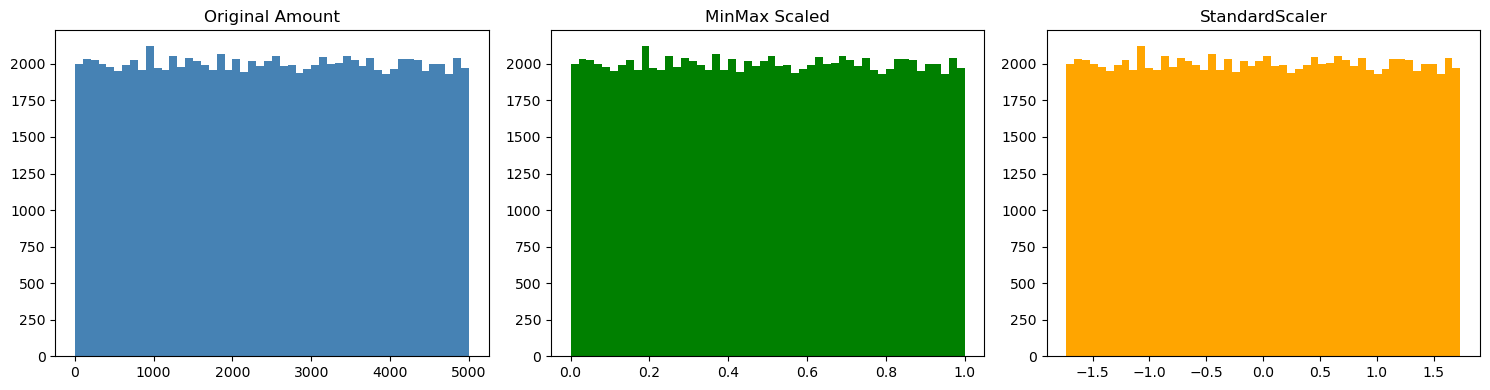

In [29]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# ── MinMax Scaling ───────────────────────────────────────────────────────────
scaler_mm = MinMaxScaler()

# Before scaling
print('Before MinMax Scaling:')
print(f'  Amount min={df_orig["Amount"].min():.2f}, max={df_orig["Amount"].max():.2f}')

df_orig['Amount_MinMax'] = scaler_mm.fit_transform(df_orig[['Amount']])

# After scaling
print('After MinMax Scaling:')
print(f'  Amount_MinMax min={df_orig["Amount_MinMax"].min():.4f}, max={df_orig["Amount_MinMax"].max():.4f}')

# ── StandardScaler ───────────────────────────────────────────────────────────
scaler_ss = StandardScaler()
df_orig['Amount_Std'] = scaler_ss.fit_transform(df_orig[['Amount']])

print('\nAfter StandardScaler:')
print(f'  Amount_Std mean={df_orig["Amount_Std"].mean():.4f}, std={df_orig["Amount_Std"].std():.4f}')

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15,4))
axes[0].hist(df_orig['Amount'], bins=50, color='steelblue');   axes[0].set_title('Original Amount')
axes[1].hist(df_orig['Amount_MinMax'], bins=50, color='green'); axes[1].set_title('MinMax Scaled')
axes[2].hist(df_orig['Amount_Std'], bins=50, color='orange');   axes[2].set_title('StandardScaler')
plt.tight_layout()
plt.show()

---
# PART 4: SMOTE — Handling Class Imbalance

## The Problem
The dataset is **highly imbalanced**: only 1% of transactions are fraudulent (IsFraud=1).
A naive model that always predicts 'not fraud' gets 99% accuracy but is useless for fraud detection!

## SMOTE (Synthetic Minority Oversampling Technique)
SMOTE **creates synthetic (fake) samples** of the minority class by interpolating between existing minority samples.

```
Before SMOTE:  Fraud=1000,  Legit=99000   → 1% fraud
After SMOTE:   Fraud≈50000, Legit=99000   → ~33% fraud  (balanced)
```

**Note:** SMOTE should only be applied to the **training set**, never to the test set.

In [30]:
# Full data preparation pipeline for ML
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split

# Step 1: Reload & clean
df_ml = pd.read_csv('credit_card_fraud_dataset.csv')
df_ml.dropna(inplace=True)
df_ml.drop_duplicates(inplace=True)

# Step 2: Feature engineering from TransactionDate
df_ml['TransactionDate'] = pd.to_datetime(df_ml['TransactionDate'])
df_ml['Hour']     = df_ml['TransactionDate'].dt.hour
df_ml['DayOfWeek']= df_ml['TransactionDate'].dt.dayofweek
df_ml['Month']    = df_ml['TransactionDate'].dt.month

# Step 3: Label Encode categorical columns
le = LabelEncoder()
df_ml['TransactionType_enc'] = le.fit_transform(df_ml['TransactionType'])
df_ml['Location_enc']        = le.fit_transform(df_ml['Location'])

# Step 4: Select features
FEATURES = ['Amount', 'MerchantID', 'TransactionType_enc', 'Location_enc',
            'Hour', 'DayOfWeek', 'Month']
TARGET   = 'IsFraud'

X = df_ml[FEATURES]
y = df_ml[TARGET]

# Step 5: MinMax Scaling
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURES)

print('Class distribution BEFORE SMOTE:')
print(y.value_counts())
print(f'Fraud %: {y.mean()*100:.2f}%')

Class distribution BEFORE SMOTE:
IsFraud
0    99000
1     1000
Name: count, dtype: int64
Fraud %: 1.00%


In [31]:
# SMOTE — Try imblearn if available, else use manual oversampling
try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_res, y_res = smote.fit_resample(X_scaled, y)
    print('SMOTE (imblearn) applied successfully')
except ImportError:
    # Manual oversampling fallback
    print('imblearn not installed — using manual oversampling as fallback')
    print('Install with: pip install imbalanced-learn')
    fraud_idx = y[y == 1].index
    n_repeat  = int(y[y == 0].shape[0] / y[y == 1].shape[0]) - 1
    X_over = pd.concat([X_scaled, X_scaled.loc[fraud_idx].sample(frac=n_repeat, replace=True, random_state=42)])
    y_over = pd.concat([y, y.loc[fraud_idx].sample(frac=n_repeat, replace=True, random_state=42)])
    X_res, y_res = X_over.values, y_over.values

import numpy as np
print('Class distribution AFTER SMOTE:')
unique, counts = np.unique(y_res, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {u}: {c}')

# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print(f'\nTrain size: {X_train.shape}, Test size: {X_test.shape}')

SMOTE (imblearn) applied successfully
Class distribution AFTER SMOTE:
  Class 0: 99000
  Class 1: 99000

Train size: (158400, 7), Test size: (39600, 7)


---
# PART 5: REGRESSION ANALYSIS

Although credit card fraud detection is a **classification** task, regression is a fundamental ML technique you must know.

We will predict **transaction Amount** to demonstrate:
1. Simple Linear Regression  
2. Multiple Linear Regression  
3. Polynomial Regression

| Type | Formula | Use case |
|------|---------|----------|
| Simple Linear | y = β₀ + β₁x | One predictor |
| Multiple Linear | y = β₀ + β₁x₁ + β₂x₂ + ... | Multiple predictors |
| Polynomial | y = β₀ + β₁x + β₂x² + ... | Non-linear relationships |

=== Simple Linear Regression ===
Coefficient (slope): 0.0006
Intercept:           2497.4017
Formula: Amount = 2497.40 + 0.0006 * MerchantID
R² Score:  -0.0000
RMSE:      1441.22


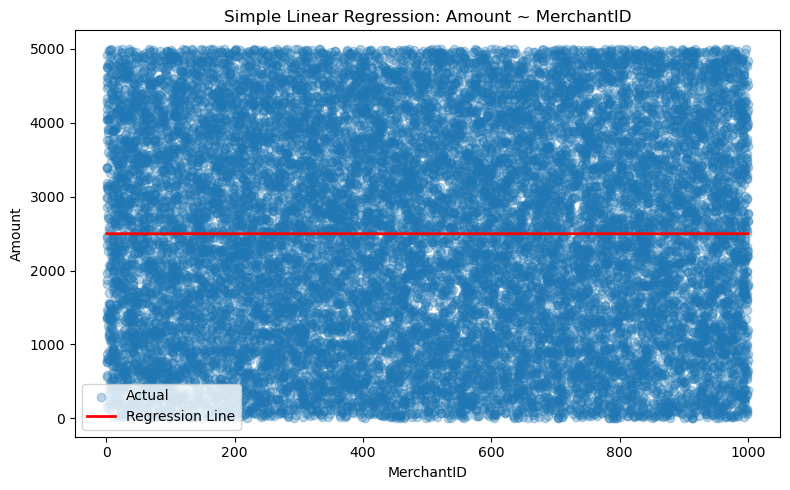

In [32]:
# ── Simple Linear Regression ─────────────────────────────────────────────────
# Predict Amount using MerchantID (one predictor)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df_reg = pd.read_csv('credit_card_fraud_dataset.csv').dropna()

X_simple = df_reg[['MerchantID']]
y_reg    = df_reg['Amount']

X_tr, X_te, y_tr, y_te = train_test_split(X_simple, y_reg, test_size=0.2, random_state=42)

slr = LinearRegression()
slr.fit(X_tr, y_tr)
y_pred_slr = slr.predict(X_te)

print('=== Simple Linear Regression ===')
print(f'Coefficient (slope): {slr.coef_[0]:.4f}')
print(f'Intercept:           {slr.intercept_:.4f}')
print(f'Formula: Amount = {slr.intercept_:.2f} + {slr.coef_[0]:.4f} * MerchantID')
print(f'R² Score:  {r2_score(y_te, y_pred_slr):.4f}')
print(f'RMSE:      {np.sqrt(mean_squared_error(y_te, y_pred_slr)):.2f}')

# Plot
plt.figure(figsize=(8,5))
plt.scatter(X_te, y_te, alpha=0.3, label='Actual')
plt.plot(sorted(X_te.values), slr.predict(sorted(X_te.values)), 'r-', lw=2, label='Regression Line')
plt.xlabel('MerchantID'); plt.ylabel('Amount')
plt.title('Simple Linear Regression: Amount ~ MerchantID')
plt.legend(); plt.tight_layout(); plt.show()

In [33]:
# ── Multiple Linear Regression ───────────────────────────────────────────────
# Predict Amount using multiple features

from sklearn.preprocessing import LabelEncoder

df_mreg = pd.read_csv('credit_card_fraud_dataset.csv').dropna()
df_mreg['TransactionDate'] = pd.to_datetime(df_mreg['TransactionDate'])
df_mreg['Hour']      = df_mreg['TransactionDate'].dt.hour
df_mreg['DayOfWeek'] = df_mreg['TransactionDate'].dt.dayofweek

le2 = LabelEncoder()
df_mreg['TransactionType_enc'] = le2.fit_transform(df_mreg['TransactionType'])
df_mreg['Location_enc']        = le2.fit_transform(df_mreg['Location'])

MULTI_FEATURES = ['MerchantID','TransactionType_enc','Location_enc','Hour','DayOfWeek','IsFraud']
X_multi = df_mreg[MULTI_FEATURES]
y_multi = df_mreg['Amount']

Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(Xm_tr, ym_tr)
ym_pred = mlr.predict(Xm_te)

print('=== Multiple Linear Regression ===')
for feat, coef in zip(MULTI_FEATURES, mlr.coef_):
    print(f'  {feat:25s}: {coef:.4f}')
print(f'Intercept: {mlr.intercept_:.4f}')
print(f'R² Score:  {r2_score(ym_te, ym_pred):.4f}')
print(f'RMSE:      {np.sqrt(mean_squared_error(ym_te, ym_pred)):.2f}')

=== Multiple Linear Regression ===
  MerchantID               : 0.0007
  TransactionType_enc      : -5.0154
  Location_enc             : -0.5529
  Hour                     : 0.2537
  DayOfWeek                : -3.3679
  IsFraud                  : 30.0632
Intercept: 2509.2912
R² Score:  -0.0001
RMSE:      1441.32


In [34]:
# ── Polynomial Regression ────────────────────────────────────────────────────
# Fits a curve instead of a straight line (degree=2 means x, x², intercept)
# Use when the relationship between X and y is non-linear

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

X_poly = df_reg[['MerchantID']]
y_poly = df_reg['Amount']

Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

results = {}
for degree in [1, 2, 3, 5]:
    poly_pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr',   LinearRegression())
    ])
    poly_pipe.fit(Xp_tr, yp_tr)
    y_p = poly_pipe.predict(Xp_te)
    r2  = r2_score(yp_te, y_p)
    rmse = np.sqrt(mean_squared_error(yp_te, y_p))
    results[degree] = {'r2': r2, 'rmse': rmse}
    print(f'Degree {degree}: R²={r2:.4f}, RMSE={rmse:.2f}')

# Note: Higher degree → better training fit but may OVERFIT (covered in Part 8)
print('\nNote: Notice how higher degree fits training data better but risks overfitting!')

Degree 1: R²=-0.0000, RMSE=1441.22
Degree 2: R²=-0.0000, RMSE=1441.25
Degree 3: R²=-0.0000, RMSE=1441.24
Degree 5: R²=-0.0001, RMSE=1441.29

Note: Notice how higher degree fits training data better but risks overfitting!


---
# PART 6: CLASSIFICATION MODELS

We evaluate multiple classifiers on the fraud detection task.

| Model | Type | Strength |
|-------|------|----------|
| Logistic Regression | Linear | Fast, interpretable, baseline |
| KNN | Instance-based | Simple, no training phase |
| SVM | Kernel-based | Powerful for high-dimensional data |
| Random Forest | **Bagging** | Robust, handles missing values |
| Gradient Boosting | **Boosting** | Usually top performer |

## Bagging vs Boosting
- **Bagging** (e.g., Random Forest): Train many models **in parallel** on random subsets → reduce variance
- **Boosting** (e.g., GradientBoosting, XGBoost): Train models **sequentially**, each one corrects the errors of the previous → reduce bias

## Key Metrics
- **Accuracy**: (TP + TN) / All — misleading for imbalanced data!
- **F1 Score**: 2 * (Precision * Recall) / (Precision + Recall) — best for imbalanced data
- **Precision**: TP / (TP + FP) — 'of predicted frauds, how many are real?'
- **Recall**: TP / (TP + FN) — 'of actual frauds, how many did we catch?'

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score, f1_score

# ====================== FASTER VERSION ======================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    
    # Removed slow SVM or made it optional with linear kernel
    # 'SVM (RBF kernel)': SVC(kernel='rbf', random_state=42, probability=True),  # ← Comment this out
    
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),  # No n_jobs
    
    'Bagging Classifier': BaggingClassifier(n_estimators=50, random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f'Training {name}... ', end='')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results[name] = {'Accuracy': acc, 'F1 Score': f1}
    print(f'Done! Acc: {acc:.4f}, F1: {f1:.4f}')

# ====================== Display Results ======================
print('\n' + '='*70)
print(f'{"Model":<25} {"Accuracy":>12} {"F1 Score":>12}')
print('='*70)

for name, m in results.items():
    print(f'{name:<25} {m["Accuracy"]:>12.4f} {m["F1 Score"]:>12.4f}')

Training Logistic Regression... Done! Acc: 0.5133, F1: 0.5133
Done! Acc: 0.9392, F1: 0.9389
Done! Acc: 0.9947, F1: 0.9947
Done! Acc: 0.9467, F1: 0.9466 
Done! Acc: 0.9936, F1: 0.9936. 

Model                         Accuracy     F1 Score
Logistic Regression             0.5133       0.5133
KNN (k=5)                       0.9392       0.9389
Random Forest                   0.9947       0.9947
Gradient Boosting               0.9467       0.9466
Bagging Classifier              0.9936       0.9936


=== Random Forest — Detailed Report ===

              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99     19800
       Fraud       1.00      0.99      0.99     19800

    accuracy                           0.99     39600
   macro avg       0.99      0.99      0.99     39600
weighted avg       0.99      0.99      0.99     39600



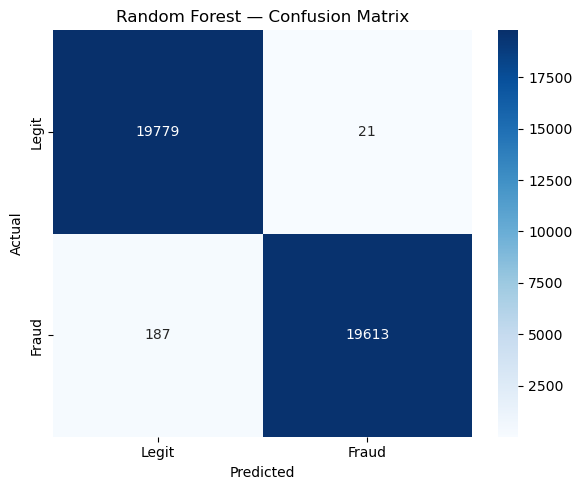


Confusion Matrix Interpretation:
True Negatives  (correctly predicted Legit) : 19779
False Positives (Legit wrongly predicted as Fraud): 21
False Negatives (Fraud missed - Very Dangerous!)   : 187  ← Minimize this!
True Positives  (correctly caught Fraud)       : 19613


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ====================== Detailed Report for Random Forest ======================
rf_model = models['Random Forest']
y_pred_rf = rf_model.predict(X_test)

print('=== Random Forest — Detailed Report ===\n')
print(classification_report(y_test, y_pred_rf, target_names=['Legit', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], 
            yticklabels=['Legit', 'Fraud'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Interpretation
print('\nConfusion Matrix Interpretation:')
print(f'True Negatives  (correctly predicted Legit) : {cm[0,0]}')
print(f'False Positives (Legit wrongly predicted as Fraud): {cm[0,1]}')
print(f'False Negatives (Fraud missed - Very Dangerous!)   : {cm[1,0]}  ← Minimize this!')
print(f'True Positives  (correctly caught Fraud)       : {cm[1,1]}')

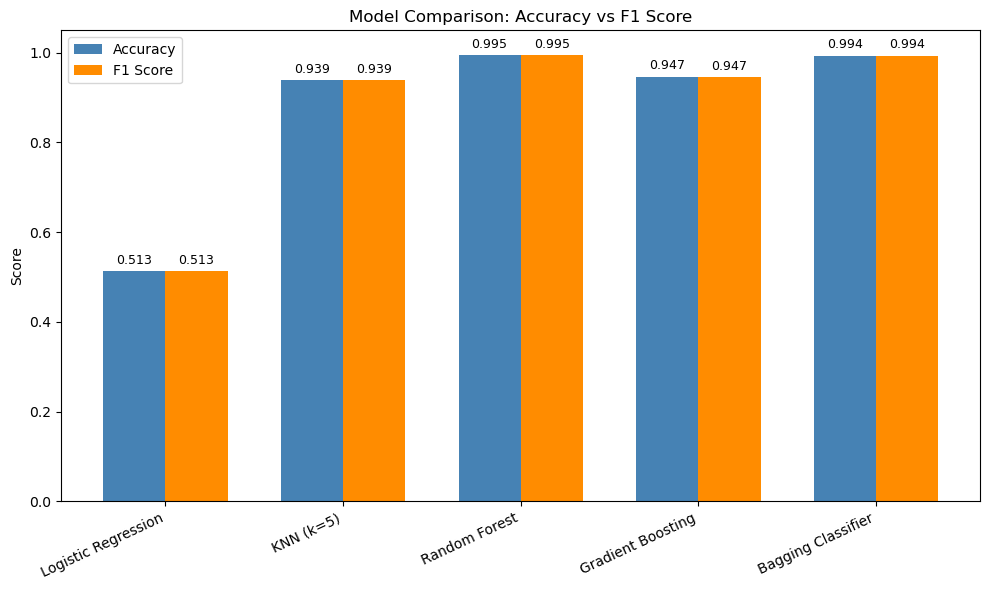

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
model_names = list(results.keys())
accuracies = [results[m]['Accuracy'] for m in model_names]
f1_scores = [results[m]['F1 Score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

# Create plot
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='darkorange')

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy vs F1 Score')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=25, ha='right')
ax.set_ylim(0, 1.05)
ax.legend()

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
# PART 7: K-MEANS CLUSTERING

K-Means is an **unsupervised** learning algorithm — it finds natural groupings in data **without labeled output**.

## How it works:
1. Pick K random centroids
2. Assign each point to the nearest centroid
3. Update centroid to mean of its assigned points
4. Repeat steps 2-3 until convergence

## Choosing K — Elbow Method
Plot inertia (within-cluster sum of squares) vs K. The 'elbow' point is the optimal K.

## Use in Fraud Detection
Cluster transactions into groups. Fraudulent transactions may form a **separate, small cluster** with unusual characteristics.

Data ready for clustering: 100000 samples, 6 features
Calculating Elbow Method...
K = 2 → Inertia = 2372.52
K = 3 → Inertia = 2159.21
K = 4 → Inertia = 1949.49
K = 5 → Inertia = 1831.88
K = 6 → Inertia = 1716.60
K = 7 → Inertia = 1628.52
K = 8 → Inertia = 1548.73
K = 9 → Inertia = 1486.79
K = 10 → Inertia = 1428.16
K = 11 → Inertia = 1376.04


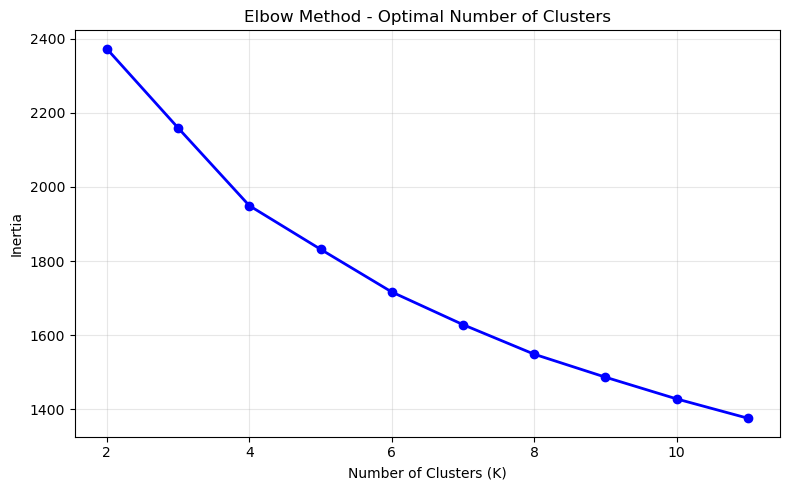

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load data
df_km = pd.read_csv('credit_card_fraud_dataset.csv').dropna()

# Feature Engineering
df_km['TransactionDate'] = pd.to_datetime(df_km['TransactionDate'])
df_km['Hour'] = df_km['TransactionDate'].dt.hour
df_km['DayOfWeek'] = df_km['TransactionDate'].dt.dayofweek

# Encode categorical columns
le = LabelEncoder()
df_km['TransactionType_enc'] = le.fit_transform(df_km['TransactionType'])
df_km['Location_enc'] = le.fit_transform(df_km['Location'])

# Features for clustering
KM_FEATURES = ['Amount', 'MerchantID', 'TransactionType_enc', 'Location_enc', 'Hour', 'DayOfWeek']
X_km = MinMaxScaler().fit_transform(df_km[KM_FEATURES])

print(f"Data ready for clustering: {X_km.shape[0]} samples, {X_km.shape[1]} features")

# ====================== ELBOW METHOD ======================
X_sample = X_km[:5000]   # Use sample for speed

inertias = []
K_range = range(2, 12)

print("Calculating Elbow Method...")

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)   # n_jobs removed
    km.fit(X_sample)
    inertias.append(km.inertia_)
    print(f"K = {k} → Inertia = {km.inertia_:.2f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=6)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Cluster Composition:
            Amount  IsFraud
Cluster                    
0        2488.6075   0.0102
1        2496.5772   0.0105
2        2490.9798   0.0098
3        2512.2558   0.0096


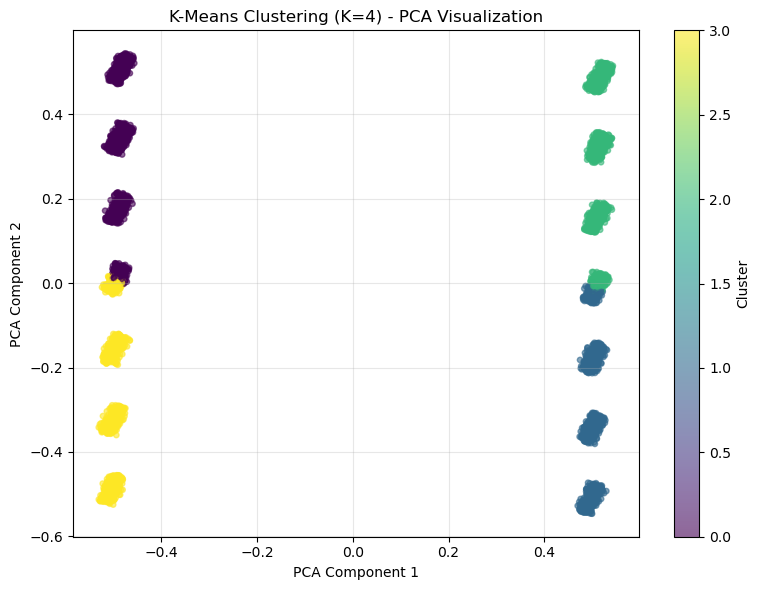

In [39]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Apply K-Means with K=4
K_OPT = 4
kmeans = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_km)

df_km['Cluster'] = cluster_labels

# Analyze clusters
print("Cluster Composition:")
print(df_km.groupby('Cluster')[['Amount', 'IsFraud']].agg({
    'Amount': 'mean', 
    'IsFraud': 'mean'
}).round(4))

# Visualize using PCA (2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_km[:5000])
c_pca = cluster_labels[:5000]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=c_pca, 
                     cmap='viridis', 
                     alpha=0.6, 
                     s=15)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clustering (K={K_OPT}) - PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# PART 8: OVERFITTING AND UNDERFITTING

## The Bias-Variance Tradeoff

```
Underfitting ←─────────────────────────────────────→ Overfitting
  High Bias                                            High Variance
  Model too simple                                     Model too complex
  Bad on training AND test data                       Good on training, BAD on test
```

## Symptoms
| | Training Accuracy | Test Accuracy |
|--|--|--|
| **Underfitting** | Low | Low |
| **Good fit** | High | High (close to training) |
| **Overfitting** | Very High | Low |

## Solutions
- **Underfitting**: More features, more complex model, less regularization
- **Overfitting**: More data, regularization (L1/L2), dropout, pruning, cross-validation, SMOTE

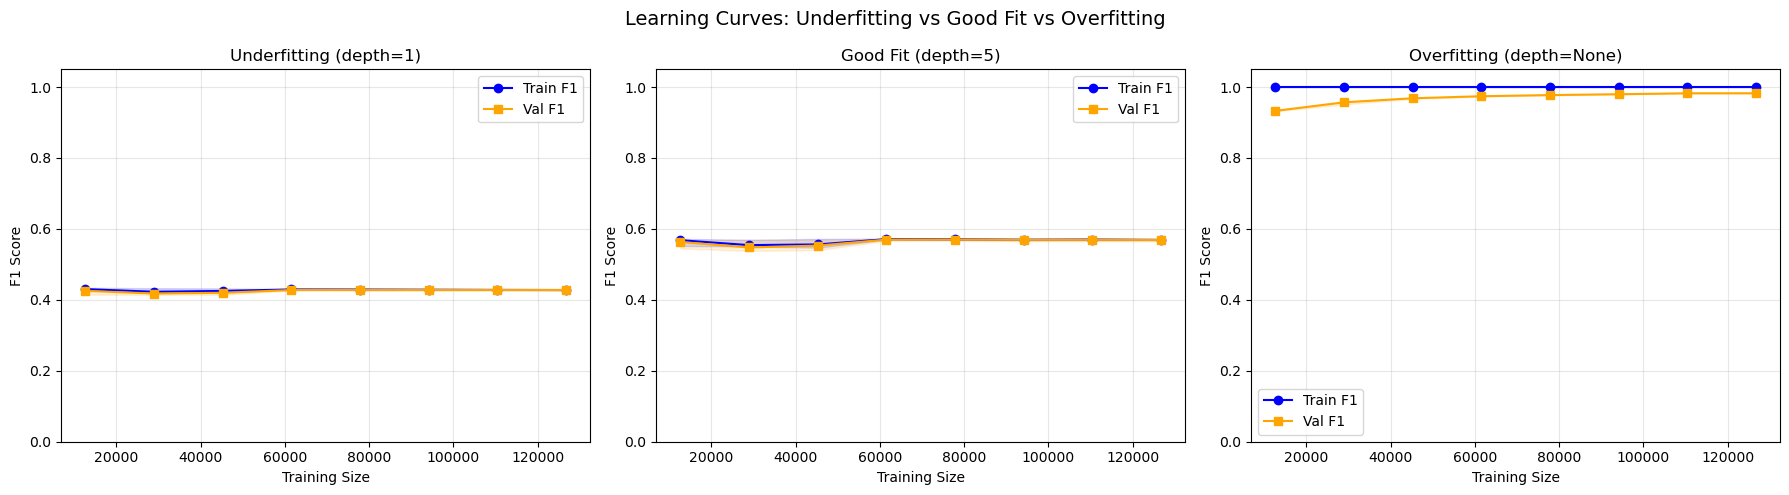

Key Observations:
• Underfitting (depth=1) : Both train & val scores are low
• Good Fit (depth=5)     : High scores and close to each other
• Overfitting (depth=None): Train score near 1.0, but val score much lower


In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.tree import DecisionTreeClassifier

# Compare Underfitting vs Good Fit vs Overfitting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    ('Underfitting (depth=1)', DecisionTreeClassifier(max_depth=1, random_state=42)),
    ('Good Fit (depth=5)', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('Overfitting (depth=None)', DecisionTreeClassifier(max_depth=None, random_state=42))
]

for ax, (title, model) in zip(axes, configs):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, 
        cv=5, 
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='f1_weighted', 
        n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    
    ax.plot(train_sizes, train_mean, 'o-', label='Train F1', color='blue')
    ax.plot(train_sizes, val_mean, 's-', label='Val F1', color='orange')
    
    ax.fill_between(train_sizes, train_scores.min(axis=1), train_scores.max(axis=1), 
                    alpha=0.15, color='blue')
    ax.fill_between(train_sizes, val_scores.min(axis=1), val_scores.max(axis=1), 
                    alpha=0.15, color='orange')
    
    ax.set_title(title)
    ax.set_xlabel('Training Size')
    ax.set_ylabel('F1 Score')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Curves: Underfitting vs Good Fit vs Overfitting', fontsize=14)
plt.tight_layout()
plt.show()

# Key Observations
print("Key Observations:")
print("• Underfitting (depth=1) : Both train & val scores are low")
print("• Good Fit (depth=5)     : High scores and close to each other")
print("• Overfitting (depth=None): Train score near 1.0, but val score much lower")

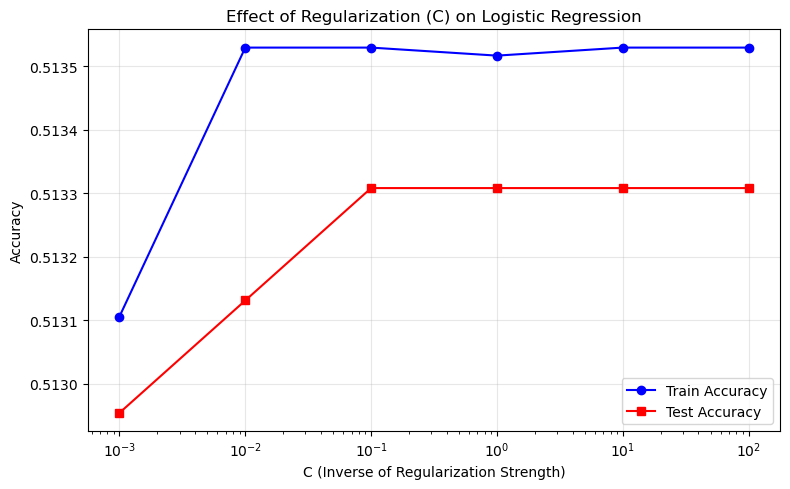

Interpretation:
• Low C  → Strong Regularization → Underfitting (lower accuracy)
• High C → Weak Regularization  → Risk of Overfitting


In [41]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Regularization effect on Logistic Regression
C_values = [0.001, 0.01, 0.1, 1, 10, 100]

train_accs = []
test_accs = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    train_accs.append(lr.score(X_train, y_train))
    test_accs.append(lr.score(X_test, y_test))

# Plot
plt.figure(figsize=(8, 5))
plt.semilogx(C_values, train_accs, 'bo-', label='Train Accuracy')
plt.semilogx(C_values, test_accs, 'rs-', label='Test Accuracy')
plt.xlabel('C (Inverse of Regularization Strength)')
plt.ylabel('Accuracy')
plt.title('Effect of Regularization (C) on Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretation
print("Interpretation:")
print("• Low C  → Strong Regularization → Underfitting (lower accuracy)")
print("• High C → Weak Regularization  → Risk of Overfitting")

---
# PART 9: HYPERPARAMETER TUNING

**Hyperparameters** are settings that are NOT learned during training — you set them before training.

Examples:
- Random Forest: `n_estimators`, `max_depth`, `min_samples_split`
- SVM: `C`, `kernel`, `gamma`
- KNN: `n_neighbors`, `weights`

## Methods

| Method | Strategy | Speed | Coverage |
|--------|----------|-------|----------|
| **GridSearchCV** | Try ALL combinations | Slow | Exhaustive |
| **RandomizedSearchCV** | Try RANDOM subset | Fast | Approximate |
| **BayesSearchCV** | Learn from previous trials | Fastest | Smart |

**Cross-Validation** is built into both — it splits training data into K folds and evaluates each combination K times to get a robust estimate.

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Grid Search for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

print(f"Running GridSearchCV... (Total combinations: {3*3*2} × 3 folds = {3*3*2*3} fits)")

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

# Use sample for faster execution (change to full data in production)
SAMPLE = min(5000, len(X_train))
grid_rf.fit(X_train[:SAMPLE], y_train[:SAMPLE])

# Results
print("\n✅ GridSearchCV Completed!")
print(f"Best Parameters : {grid_rf.best_params_}")
print(f"Best CV F1 Score: {grid_rf.best_score_:.4f}")

# Evaluate on test set
best_rf = grid_rf.best_estimator_
y_pred_best = best_rf.predict(X_test)
test_f1 = f1_score(y_test, y_pred_best, average='weighted')

print(f"Test F1 Score   : {test_f1:.4f}")

Running GridSearchCV... (Total combinations: 18 × 3 folds = 54 fits)
Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ GridSearchCV Completed!
Best Parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1 Score: 0.9267
Test F1 Score   : 0.9430


In [43]:
# ── RandomizedSearchCV ───────────────────────────────────────────────────────
# Tries a RANDOM subset of combinations → much faster than GridSearch
# Best for large hyperparameter spaces

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from scipy.stats import randint

# Randomized Search for Random Forest (Faster than GridSearch)
param_dist_rf = {
    'n_estimators': randint(50, 300),
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

print("Running RandomizedSearchCV (20 random combinations)...")

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,          # Number of random combinations to try
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Use sample for faster training
SAMPLE = min(5000, len(X_train))
random_rf.fit(X_train[:SAMPLE], y_train[:SAMPLE])

# Results
print("\n✅ RandomizedSearchCV Completed!")
print(f"Best Parameters : {random_rf.best_params_}")
print(f"Best CV F1 Score: {random_rf.best_score_:.4f}")

# Evaluate on test set
best_model = random_rf.best_estimator_
y_pred_rand = best_model.predict(X_test)
test_f1 = f1_score(y_test, y_pred_rand, average='weighted')

print(f"Test F1 Score   : {test_f1:.4f}")

Running RandomizedSearchCV (20 random combinations)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ RandomizedSearchCV Completed!
Best Parameters : {'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 58}
Best CV F1 Score: 0.9340
Test F1 Score   : 0.9479


In [44]:
# ── Cross-Validation Score (standalone) ──────────────────────────────────────
# Use cross_val_score when you just want a robust estimate without hyperparameter search

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Cross-Validation with StratifiedKFold
cv_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=10, 
    random_state=42, 
    n_jobs=-1
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Running 5-Fold Stratified Cross-Validation...")

cv_scores = cross_val_score(
    cv_model, 
    X_res[:5000], 
    y_res[:5000], 
    cv=skf, 
    scoring='f1_weighted', 
    n_jobs=-1
)

# Results
print("\n5-Fold Cross-Validation F1 Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f" Fold {i}: {score:.4f}")

print(f"\nMean F1 Score : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Running 5-Fold Stratified Cross-Validation...

5-Fold Cross-Validation F1 Scores:
 Fold 1: 0.9850
 Fold 2: 0.9850
 Fold 3: 0.9835
 Fold 4: 0.9835
 Fold 5: 0.9835

Mean F1 Score : 0.9841 ± 0.0007


---
# PART 10: STREAMLIT DEPLOYMENT WITH GITHUB ACTIONS

## Architecture
```
You push code to GitHub
    ↓
GitHub Actions runs tests automatically (CI)
    ↓
Streamlit Community Cloud detects the push
    ↓
Auto-deploys the updated app (CD)
```

## Files you need
```
your-repo/
├── app.py                         # Streamlit application
├── requirements.txt               # Python dependencies
├── model/
│   └── fraud_model.pkl            # Saved ML model
└── .github/
    └── workflows/
        └── deploy.yml             # GitHub Actions CI/CD
```

## One-time setup (only done once)
1. Push your repo to GitHub
2. Go to https://share.streamlit.io
3. Connect your GitHub account → select repo → click Deploy
4. After that, every `git push` auto-redeploys!

In [ ]:
# Run this cell to save the trained model and create all deployment files
import pickle, os

# Save the best model
os.makedirs('model', exist_ok=True)
with open('model/fraud_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

# Also save the scaler
with open('model/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Model and scaler saved to model/ directory')

In [ ]:
# ── Create app.py ─────────────────────────────────────────────────────────────
APP_PY = '''
import streamlit as st
import pandas as pd
import numpy as np
import pickle

# ── Page config ──────────────────────────────────────────────────────────────
st.set_page_config(
    page_title="Credit Card Fraud Detector",
    page_icon="💳",
    layout="wide"
)

# ── Load model ────────────────────────────────────────────────────────────────
@st.cache_resource
def load_model():
    with open("model/fraud_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("model/scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    return model, scaler

model, scaler = load_model()

# ── UI ────────────────────────────────────────────────────────────────────────
st.title("💳 Credit Card Fraud Detection")
st.markdown("Enter transaction details to predict whether it is **fraudulent** or **legitimate**.")

col1, col2 = st.columns(2)

with col1:
    amount       = st.number_input("Transaction Amount ($)", 0.0, 10000.0, 500.0)
    merchant_id  = st.number_input("Merchant ID", 1, 1000, 100)
    tx_type      = st.selectbox("Transaction Type", ["purchase", "refund"])

with col2:
    location     = st.selectbox("Location", ["New York","Los Angeles","Chicago","Houston",
                                              "Phoenix","Philadelphia","San Antonio","Dallas"])
    hour         = st.slider("Hour of Transaction", 0, 23, 12)
    day_of_week  = st.slider("Day of Week (0=Mon, 6=Sun)", 0, 6, 2)
    month        = st.slider("Month", 1, 12, 6)

# ── Encode inputs (must match training pipeline) ─────────────────────────────
TYPE_MAP     = {"purchase": 1, "refund": 0}
LOCATION_MAP = {"Chicago":0,"Dallas":1,"Houston":2,"Los Angeles":3,
                "New York":4,"Philadelphia":5,"Phoenix":6,"San Antonio":7}

features = np.array([[amount, merchant_id,
                       TYPE_MAP[tx_type],
                       LOCATION_MAP.get(location, 0),
                       hour, day_of_week, month]])

features_scaled = scaler.transform(
    pd.DataFrame(features,
                 columns=["Amount","MerchantID","TransactionType_enc",
                          "Location_enc","Hour","DayOfWeek","Month"])
)

# ── Predict ───────────────────────────────────────────────────────────────────
if st.button("🔍 Detect Fraud", type="primary"):
    prediction = model.predict(features_scaled)[0]
    proba      = model.predict_proba(features_scaled)[0]

    if prediction == 1:
        st.error(f"🚨 **FRAUDULENT TRANSACTION DETECTED!**")
        st.metric("Fraud Probability", f"{proba[1]*100:.1f}%")
    else:
        st.success(f"✅ **LEGITIMATE TRANSACTION**")
        st.metric("Legitimate Probability", f"{proba[0]*100:.1f}%")

    # Probability bar chart
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(5, 2))
    ax.barh(["Legitimate","Fraud"], [proba[0], proba[1]],
            color=["green" if prediction==0 else "gray",
                   "red"   if prediction==1 else "gray"])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Probability")
    ax.set_title("Prediction Probabilities")
    st.pyplot(fig)

# ── Footer ────────────────────────────────────────────────────────────────────
st.markdown("---")
st.caption("Built with Streamlit · Model: Random Forest · Dataset: 100K transactions")
'''

with open('app.py', 'w') as f:
    f.write(APP_PY.lstrip())

print('app.py created successfully!')

In [ ]:
# ── Create requirements.txt ───────────────────────────────────────────────────
REQUIREMENTS = '''streamlit>=1.28.0
scikit-learn>=1.3.0
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
imbalanced-learn>=0.11.0
'''

with open('requirements.txt', 'w') as f:
    f.write(REQUIREMENTS)

print('requirements.txt created!')
print(REQUIREMENTS)

In [ ]:
# ── Create GitHub Actions Workflow ────────────────────────────────────────────
import os

os.makedirs('.github/workflows', exist_ok=True)

WORKFLOW = '''name: CI/CD — Test and Deploy Fraud Detector

on:
  push:
    branches: [ main ]       # triggers on every push to main
  pull_request:
    branches: [ main ]       # also runs on PRs for review

jobs:
  # ─────────────────────────────────────────────────────────────────────────
  # JOB 1: Run tests (CI)
  # ─────────────────────────────────────────────────────────────────────────
  test:
    name: Run Tests
    runs-on: ubuntu-latest

    steps:
      - name: Checkout code
        uses: actions/checkout@v4

      - name: Set up Python 3.11
        uses: actions/setup-python@v5
        with:
          python-version: "3.11"
          cache: "pip"

      - name: Install dependencies
        run: |
          pip install --upgrade pip
          pip install -r requirements.txt
          pip install pytest

      - name: Check app.py syntax
        run: python -m py_compile app.py && echo "✅ app.py syntax OK"

      - name: Run unit tests (if test files exist)
        run: |
          if ls tests/test_*.py 1> /dev/null 2>&1; then
            pytest tests/ -v
          else
            echo "No test files found, skipping pytest."
          fi

  # ─────────────────────────────────────────────────────────────────────────
  # JOB 2: Notify on success (Streamlit Cloud auto-deploys after CI passes)
  # ─────────────────────────────────────────────────────────────────────────
  notify-deploy:
    name: Notify Deployment
    needs: test              # only runs if "test" job passes
    runs-on: ubuntu-latest
    if: github.ref == \'refs/heads/main\' && github.event_name == \'push\'

    steps:
      - name: Deployment notification
        run: |
          echo "✅ Tests passed. Streamlit Cloud will auto-deploy from main branch."
          echo "   App URL: https://share.streamlit.io/<YOUR-USERNAME>/<YOUR-REPO>/main/app.py"
          echo "   Commit: ${{ github.sha }}"
          echo "   Author: ${{ github.actor }}"
'''

with open('.github/workflows/deploy.yml', 'w') as f:
    f.write(WORKFLOW)

print('.github/workflows/deploy.yml created!')

---
# ✅ DEPLOYMENT CHECKLIST

## Step-by-Step: Auto-Deploy to Streamlit Community Cloud

### 1. Prepare your repository
```bash
# In your project folder:
git init
git add .
git commit -m 'Initial commit: fraud detection app'
git branch -M main
git remote add origin https://github.com/YOUR-USERNAME/fraud-detector.git
git push -u origin main
```

### 2. Deploy on Streamlit Community Cloud (FREE)
1. Go to **https://share.streamlit.io** → Sign in with GitHub
2. Click **'New app'** → Select your repository
3. Set: Branch=`main`, Main file=`app.py`
4. Click **Deploy!**

### 3. After initial setup — FULLY AUTOMATIC
Every time you push to `main`:
```bash
git add .
git commit -m 'Update model'
git push                  # ← This auto-triggers CI/CD!
```
- GitHub Actions runs tests ✅
- Streamlit Cloud detects the push and redeploys 🚀
- **No manual intervention needed!**

### 4. Files created by this notebook
```
app.py                          # Streamlit fraud detection app
requirements.txt                # All Python dependencies
model/fraud_model.pkl           # Trained Random Forest model
model/scaler.pkl                # MinMax Scaler
.github/workflows/deploy.yml   # GitHub Actions CI/CD pipeline
```

### 5. Environment secrets (if needed)
Go to: GitHub Repo → Settings → Secrets → Actions → New repository secret
Add any API keys or sensitive values there (never put secrets in code!)

---
## 📊 Final Summary: What We Built

| Section | Technique | Purpose |
|---------|-----------|----------|
| Part 1 | EDA, Outlier Detection | Understand data |
| Part 2 | Label/Ordinal/One-Hot Encoding | Convert categories to numbers |
| Part 3 | MinMax & Standard Scaling | Normalize feature ranges |
| Part 4 | SMOTE | Balance class distribution |
| Part 5 | Linear/Polynomial Regression | Predict continuous values |
| Part 6 | LR, KNN, SVM, RF, GBM | Classify fraud vs legit |
| Part 7 | K-Means Clustering | Find natural groups |
| Part 8 | Learning Curves, Regularization | Diagnose over/underfitting |
| Part 9 | GridSearchCV, RandomizedSearchCV | Find best hyperparameters |
| Part 10 | Streamlit + GitHub Actions | Deploy app automatically |